In [1]:
pip install scikit-learn pandas matplotlib

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
data = {
    'Weather': ['Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Sunny'],
    'Activity': ['Picnic', 'Drink', 'Errands', 'Movie', 'Movie', 'Picnic', 'Movie', 'Errands'],
    'Decision': ['Go Out', 'Go Out', 'Go Out', 'Stay In', 'Stay In', 'Go Out', 'Stay In', 'Go Out']
}

df = pd.DataFrame(data)

# Encode categorical values
weather_encoder = LabelEncoder()
activity_encoder = LabelEncoder()

In [4]:
df['Weather'] = weather_encoder.fit_transform(df['Weather'])
df['Activity'] = activity_encoder.fit_transform(df['Activity'])

# Features and Target
X = df[['Weather', 'Activity']]
y = df['Decision']

# Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [5]:
new_data = [[weather_encoder.transform(['Rainy'])[0],
             activity_encoder.transform(['Movie'])[0]]]

prediction = model.predict(new_data)

print("Prediction:", prediction[0])


Prediction: Stay In


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


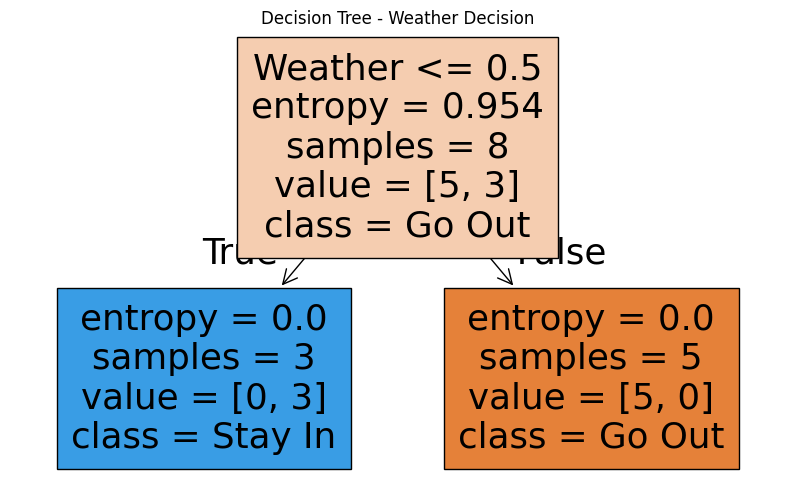

In [6]:
plt.figure(figsize=(10,6))
plot_tree(model,
          feature_names=['Weather', 'Activity'],
          class_names=model.classes_,
          filled=True)

plt.title("Decision Tree - Weather Decision")
plt.show()